## GARCH Volatility Modelling

The objective of this notebook is to model the conditional volatility of S&P 500 returns using a GARCH(1,1) model. 

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, norm
import statsmodels.api as smapi
import statsmodels as sm
import sys
from statsmodels.stats.diagnostic import acorr_ljungbox

project_root = Path.cwd().parent


if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src import data_loader as dl
from src import preprocessing as pp
from src import garch
# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)

## 1. Mathematical Background

### 1.1 Conditional Mean and Innovations

Let $r_t$ represent the return observed at time $t$. A simple constant-mean return model can be written as $r_t = \mu + \varepsilon_t$, where $\mu$ represents the expected return and $\varepsilon_t$ is the innovation/unexpected component of the return.

The innovation is then given by $\varepsilon_t = r_t - \mu$. A positive innovation indicates that the observed return exceeded its expected value, while a negative innovation indicates that it fell below its expected value. In this project, the primary objective is not to predict if returns are going to be positive or negative, instead the goal is to model the time-varying magnitude of these innovations. 

### 1.2 Conditional Variance
An important assumption of many time series models is that the variance of the innovations remains constant over time. However, as established in notebook 1, financial return series typically exhibit volatility clustering. Volatility clustering exhibits periods of high volatility that are followed by further periods of high volatility, and then calm periods that tend to persist. This implies that the variance is not constant and hence that the regression model shows heteroscedasticity.

To account for this phenomenon, the variance is allowed to depend on the information available up to time $t−1$. The conditional variance is then defined as $h_t = Var(\varepsilon_t | F_{t-1})$, where $F_{t-1}$ represents the information available before time $t$. 

The innovation component can then be written as $\varepsilon_t = v_t \sqrt{h_t}$, where $v_t$ is an independent and identically distributed random variable with mean zero and variance one. The conclusion is that the conditional variance of the innovation is determined entirely by $h_t$.


### 1.3 The GARCH(1,1) Model

To model the volatility of a time series that exhibits heteroscedasticity it is common to use the autoregressive conditional heteroscedasticity model. Engle's (1982) initial ARCH model that models conditional variance is defined as $h_t = \omega + \alpha \varepsilon_{t-1}^2$, where both $\omega$ and $\alpha$ are constants. To ensure that the conditional variance remains positive, the parameters satisfy, $\omega > 0$ and $\alpha ≥ 0$. When applying ARCH in practice, accurately modelling volatility persistence can require a large number of ARCH terms, resulting in an unnecessarily parameter-rich model.

Bollerslev (1986) extended the inital ARCH model (creating the Generlized ARCH model) that allows the conditional variance to be dependant on its own lags. This can often reduce the amount of lags needed by letting conditional variance depend on its previous values. The GARCH(1,1) model is defined as $h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}$, where $\beta ≥ 0$ and $\alpha + \beta < 1$. The GARCH(1,1) model can be interpreted as an updating equation for volatility. The current conditional variance is established by a baseline level of volatility, the magnitude of the most recent innovation, and the previous conditional variance.



## 2. Model Estimation

In [11]:
garch_output = garch.fit_garch(market_data["Return"]*100)
result = garch_output.result
print(results)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9058.52
Distribution:      Standardized Student's t   AIC:                           18127.0
Method:                  Maximum Likelihood   BIC:                           18161.1
                                              No. Observations:                 6711
Date:                      Fri, Sep 11 2026   Df Residuals:                     6710
Time:                              09:28:14   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

### 2.1 Estimated Parameters

In [12]:
params = result.params
pvalues = result.pvalues
std_err = result.std_err

summary_df = pd.DataFrame({
    "Estimate": params,
    "Std. Error": std_err,
    "P-value": pvalues
})

summary_df

,Estimate,Std. Error,P-value
mu,0.078706,0.008905,9.674035e-19
omega,0.015650,0.003159,7.267133e-07
alpha[1],0.122582,0.010732,3.257011e-30
beta[1],0.872261,0.010324,0.000000e+00
nu,6.230757,0.481518,2.682123e-38


### 2.2 Derived Quantities

To further analyse the fitted GARCH(1,1) model, there are two derived quantities that are informative: persistence, ($\alpha + \beta$), and long-run variance $ \frac{\omega}{1 - \alpha - \beta}$. These quantities combined describe how persistent volatility shocks are and the level towards which the conditional variance reverts over time. 

In [13]:
alpha = params["alpha[1]"]
beta = params["beta[1]"]
omega = params["omega"]

persistence = alpha + beta
long_run_variance = omega / (1 - persistence)

dq_df = pd.DataFrame(
    {
        "Parameter": [
            "Persistence ($\\alpha + \\beta$)",
            "Long-run Variance",
            "Long-run Volatility"
        ],
        "Value": [
            persistence,
            long_run_variance,
            np.sqrt(long_run_variance)
        ]
    }
)

dq_df["Value"] = dq_df["Value"].map("{:.6f}".format)

dq_df

,Parameter,Value
0,Persistence ($\alpha + \beta$),0.994843
1,Long-run Variance,3.034460
2,Long-run Volatility,1.741970


#### Discussion

The fitted GARCH(1,1) model indicates strong volatility persistence in S&P 500 returns. Both the ARCH and GARCH coefficients are statistically significant, suggesting that conditional volatility responds to recent return shocks while also depending heavily on its previous level.

The estimated persistence of 0.9951 is high and implies that volatility shocks decay slowly. Such high persistence is commonly observed in broad equity indices and implies that volatility persists when there is high market uncertainty. The estimated long-run volatility is approximately 1.78% per day. Post return shock the conditional volatility is expected to gradually revert towards this long-run level, although the high persistence (0.995) implies that this adjustment happens very slowly.

The estimated Student-t degrees-of-freedom parameter is approximately 6.2. This means the distribution has substantially heavier tails than under a Gaussian innovation assumption. This is consistent with the occurrence of extreme returns observed during the exploratory data analysis in notebook 1.

Although the parameter estimates are statistically significant, residual diagnostics are required before concluding that the GARCH(1,1) specification acceptably captures the conditional heteroskedasticity in the return series.

## 3. Estimated Conditional Volatility

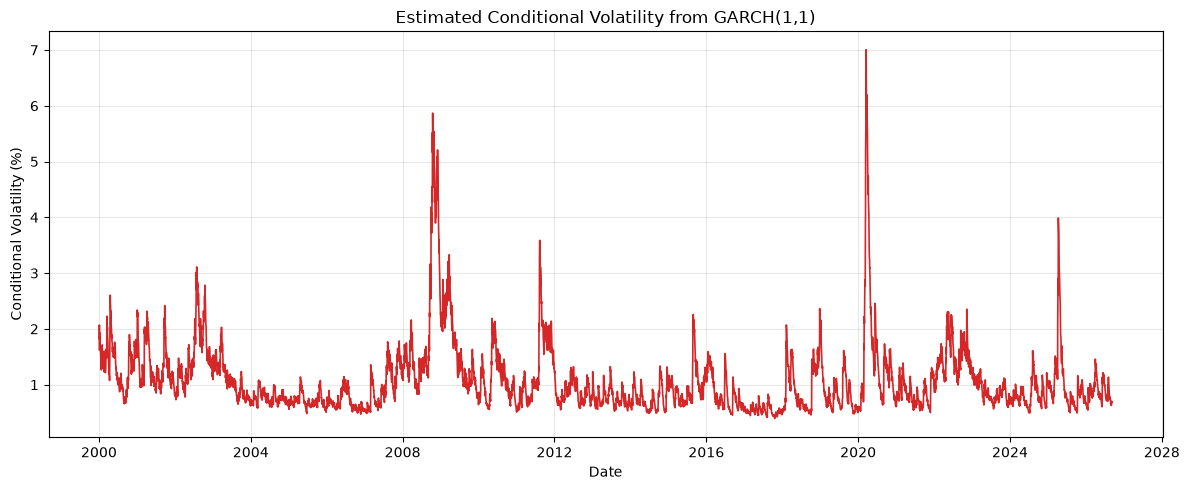

In [14]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    garch_output.conditional_volatility,
    color="tab:red",
    linewidth=1.2
)

ax.set_title("Estimated Conditional Volatility from GARCH(1,1)")
ax.set_xlabel("Date")
ax.set_ylabel("Conditional Volatility (%)")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion

The estimated conditional volatility exhibits clear periods of increased market uncertainty, with volatility spikes during the aftermath of the dot-com bubble, the 2008 global financial crisis, and the COVID-19 pandemic in 2020. These periods coincide with well-known episodes of extreme market turbulence and indicate that the GARCH(1,1) model successfully captures volatility clustering in the return series.

An important characteristic of the estimated volatility is its persistence. Following major market shocks, the conditional volatility remains elevated for an extended period before gradually reverting towards its long-run level, reflecting the high persistence estimated in the model ($\alpha+ \beta \approx 0.995$).

The estimated conditional volatility closely follows periods of large market movements and captures the well-known volatility clustering observed in the return series. This indicates that the model behaves as expected, however a visual comparison alone is not enough to determine the competence of the model. The following section examines the standardized residuals and diagnostic tests to determine whether any remaining volatility dependence is left unexplained.

### 3.1 Standardized residuals

After estimating the GARCH model, the residuals are standardized by the estimated conditional volatility, $z_t=\frac{\varepsilon_t}{\sqrt{h_t}}$.
If the model adequately captures the conditional heteroskedasticity, the standardized residuals should resemble an independent white-noise process with zero mean and unit variance.

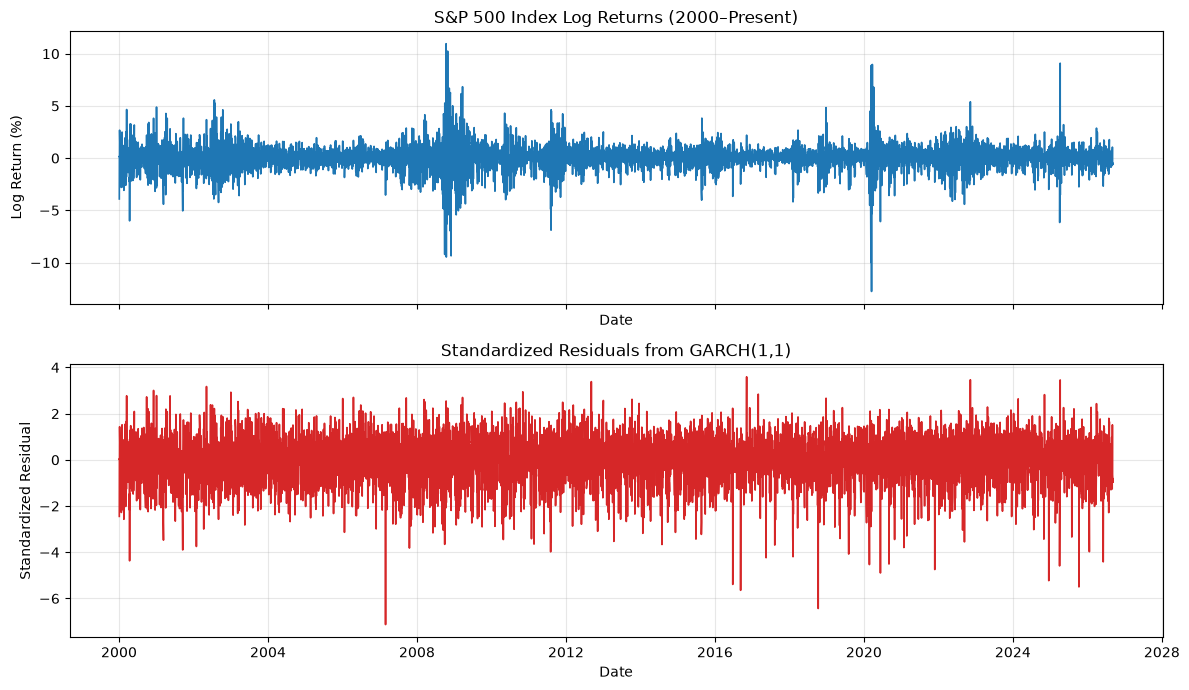

In [15]:

fig, (yx, ax) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax.plot(
    result.std_resid,
    color="tab:red",
    linewidth=1.2
)

yx.plot(
    market_data["Return"] *100,
    color="tab:blue",
    linewidth=1.2
)

ax.set_title("Standardized Residuals from GARCH(1,1)")
ax.set_xlabel("Date")
ax.set_ylabel("Standardized Residual")

ax.grid(alpha=0.3)


yx.set_title("S&P 500 Index Log Returns (2000–Present)")
yx.set_xlabel("Date")
yx.set_ylabel("Log Return (%)")

yx.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion

The standardized residuals exhibit considerably less volatility clustering than the original return series and fluctuate around zero with a more stable variance over time. This indicates that the GARCH(1,1) model successfully captures a substantial part of the conditional heteroskedasticity present in the returns. Although the volatility clustering has to an extent disappeared, several extreme residuals remain, specifically on the negative side. This suggests that some characteristics of the return distribution are still not fully captured by the model. The following diagnostic tests investigate whether any statistically significant dependence remains in the standardized residuals and whether the GARCH(1,1) model is reliable.

## 4. Diagnostics

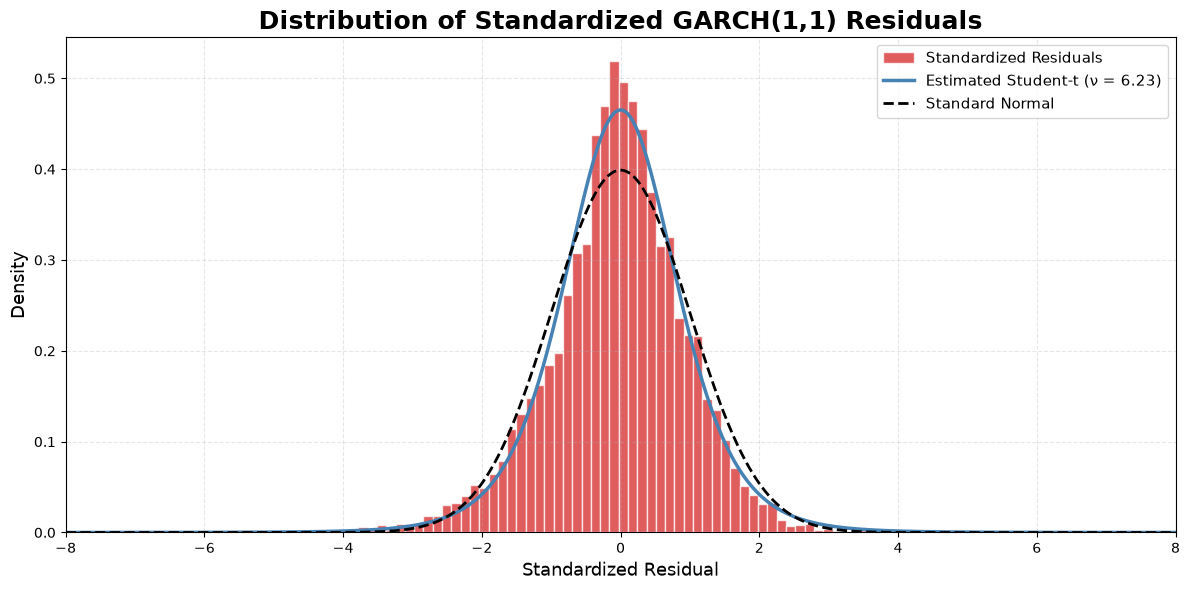

In [16]:
std_resid = result.std_resid.dropna()

# Estimated degrees of freedom
nu = result.params["nu"]

# Standardized Student-t scale
scale = np.sqrt((nu - 2) / nu)

# x-grid
x = np.linspace(-8, 8, 1000)

# PDFs
student_pdf = t.pdf(x, df=nu, loc=0, scale=scale)
normal_pdf = norm.pdf(x, loc=0, scale=1)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(12,6))

plt.hist(std_resid, bins=80, density=True, color="tab:red", edgecolor="white", alpha=0.75, label="Standardized Residuals")
plt.plot(x, student_pdf, color="steelblue", linewidth=2.5, label=f"Estimated Student-t (ν = {nu:.2f})")
plt.plot(x, normal_pdf, color="black", linestyle="--", linewidth=2, label="Standard Normal")

plt.xlim(-8,8)

plt.title("Distribution of Standardized GARCH(1,1) Residuals", fontsize=18, fontweight="bold")

plt.xlabel("Standardized Residual", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

#### Discussion

The standardized residuals are substantially closer to the fitted Student-t distribution than to the standard Gaussian distribution. While the central part of the empirical distribution is reasonably well captured, the residuals still exhibit occasional extreme observations, particularly in the left tail.

Compared with the Gaussian benchmark, the Student-t distribution assigns considerably more probability mass to large positive and negative residuals, making it a more appropriate innovation distribution for financial returns. This is consistent with the heavy-tailed behaviour observed in Notebook 1 and supported by the estimated degrees-of-freedom parameter of approximately 6.2.

The figure also suggests that the GARCH(1,1) model successfully removes a substantial part of the volatility clustering present in the raw returns. Remaining departures from the theoretical distribution will be investigated further using QQ-plots and residual autocorrelation diagnostics.

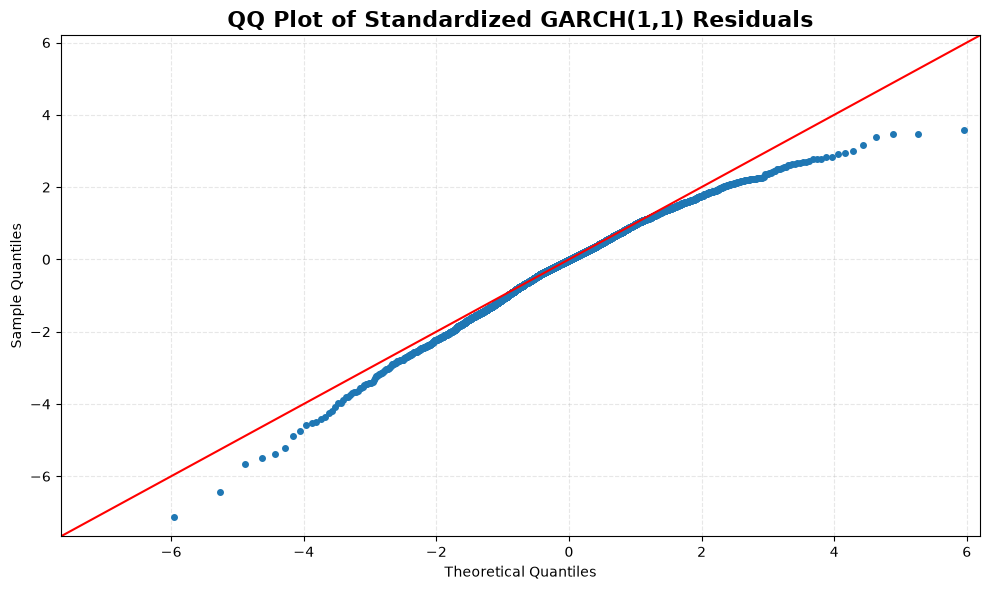

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
nu = result.params["nu"]

# Scale the Student-t distribution so that its variance equals one
student_scale = np.sqrt((nu - 2) / nu)



smapi.qqplot(std_resid, dist=t, distargs=(nu,), loc=0, scale=student_scale, fit=False, line="45", markersize=4, ax=ax)
plt.title("QQ Plot of Standardized GARCH(1,1) Residuals", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Discussion

The QQ plot compares the standardized residuals with the standardized Student-t distribution implied by the fitted GARCH(1,1) model. The residuals follow the theoretical distribution closely throughout the central quantiles, indicating that the model captures the majority of the innovation distribution. However, strong deviations remain in both tails, particularly in the lower tail, suggesting that some extreme observations are not fully explained by the fitted model. These deviations may indicate remaining asymmetry however additional residual diagnostics are required before such conclusions.

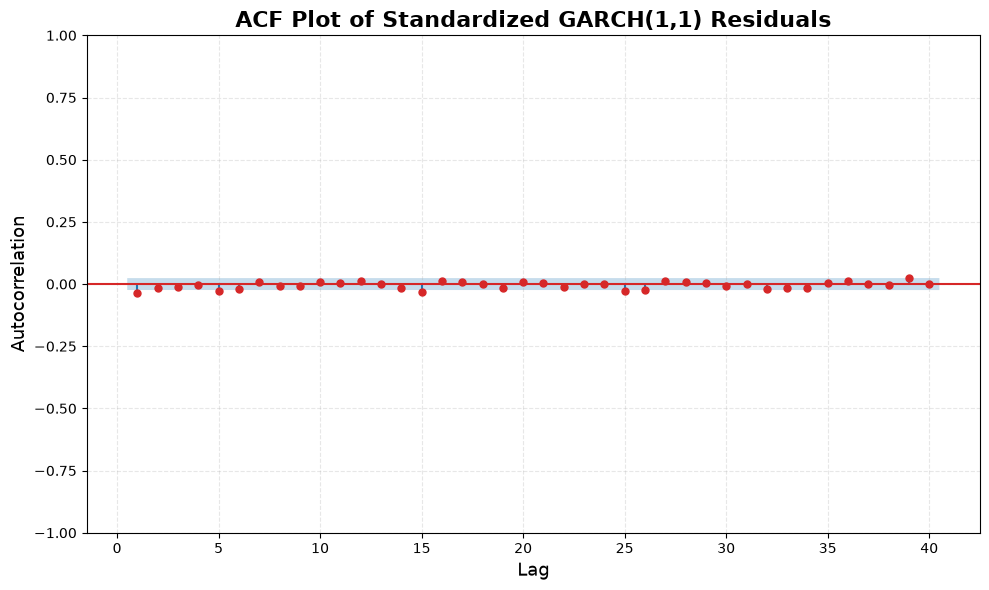

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sm.graphics.tsaplots.plot_acf(result.std_resid, lags=40, alpha=0.05, zero=False, ax=ax, color="tab:red")
plt.title("ACF Plot of Standardized GARCH(1,1) Residuals", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Autocorrelation", fontsize=13)

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


#### Discussion

The ACF plot demonstrates that the autocorrelation coefficients of standardized GARCH(1,1) residuals are small and concentrated around zero, even more so than the ACF plot for daily log returns of the S&P 500. Overall, the figure indicates that past standardized residuals contain little direct information about future standardized residuals. This implies that the linear dependence observed in the original return series has largely been removed. 

The absence of autocorrelation in the standardized residuals does not necessarily imply that the volatility dynamics have been fully captured by the GARCH(1,1) model. Financial return series often exhibit dependence in the magnitude rather than the direction of shocks. The next diagnostic examines the autocorrelation of the squared standardized residuals to determine whether any volatility clustering remains unexplained.

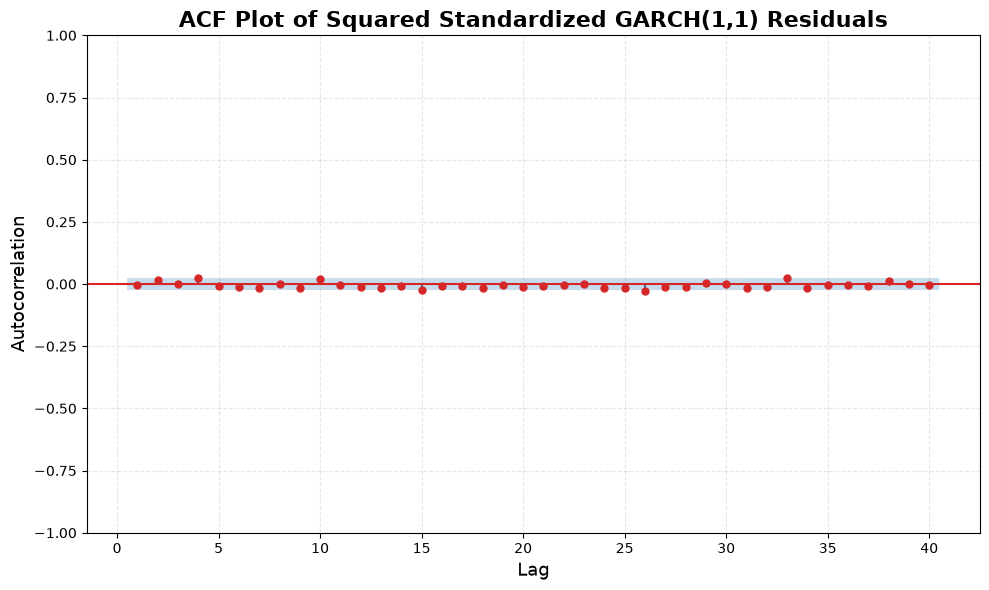

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sm.graphics.tsaplots.plot_acf(result.std_resid**2, lags=40, alpha=0.05, zero=False, ax=ax, color="tab:red")
plt.title("ACF Plot of Squared Standardized GARCH(1,1) Residuals", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Autocorrelation", fontsize=13)

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


#### Discussion

The ACF plot of the squared standardized residuals shows that the autocorrelation coefficients are close to zero across all considered lags and remain within the 95% confidence intervals. This indicates that little evidence of remaining ARCH effects exists after fitting the GARCH(1,1) model.

Compared with the ACF of the squared returns in Notebook 1, where substantial positive autocorrelation was observed, the dependence has essentially disappeared after standardization. This suggests that the GARCH(1,1) specification has successfully captured the volatility clustering present in the original return series.

Although this graphical evidence is encouraging, a formal statistical diagnostic such as the Ljung–Box test applied to the squared standardized residuals provides a better assessment of whether any remaining volatility dependence exists.

In [20]:

lb_resid = acorr_ljungbox(result.std_resid, lags=[10], model_df=0)
lb_squared = acorr_ljungbox(result.std_resid**2, lags=[10], model_df=2)

summary = pd.DataFrame({
    "Ljung Box": [
        "Ljung Box Standardized Residuals (Lag 10)",
        "Ljung Box Squared Standardized Residuals (Lag 10)"
    ],
    "p-value": [
        round(lb_resid["lb_pvalue"].iloc[0], 4),
        round(lb_squared["lb_pvalue"].iloc[0], 4)
    ]
})

summary


,Ljung Box,p-value
0,Ljung Box Standardized Residuals (Lag 10),0.0169
1,Ljung Box Squared Standardized Residuals (Lag 10),0.0965


#### Discussion

The Ljung–Box test evaluates whether significant autocorrelation remains after fitting the GARCH(1,1) model. For the standardized residuals, the test returns a p-value of 0.0169, suggesting that a small amount of linear dependence remains. However, the corresponding ACF plot indicates that these autocorrelations are limited in magnitude.

For the squared standardized residuals, the p-value is 0.0965, meaning there is insufficient evidence of remaining autocorrelation in the residual variance. This indicates that the GARCH(1,1) model has successfully captured the volatility clustering present in the original return series.

## 5. Conclusion

The GARCH(1,1) model provides a substantial improvement over modelling the return series directly. The fitted model captures the time-varying volatility observed during the exploratory analysis and produces statistically significant parameter estimates with a persistence close to one, indicating highly persistent but mean-reverting volatility.

The residual diagnostics further support the adequacy of the model. Although a small amount of autocorrelation remains in the standardized residuals, the absence of significant autocorrelation in the squared standardized residuals suggests that the model successfully explains the conditional heteroskedasticity and volatility clustering present in the data.

While more advanced asymmetric volatility models, such as EGARCH or GJR-GARCH, may further improve the modelling of leverage effects, the current GARCH(1,1) specification provides a robust foundation for the remainder of the project.

The estimated conditional volatility series will therefore be used in the subsequent notebooks as an input feature for market regime identification using Hidden Markov Models and, ultimately, for volatility forecasting.